# Taller complementario de Red Neuronal Densas para Regresión

Este taller tiene como objetivo construir y entrenar una red neuronal simple para un problema de regresión usando Python.


Este código importa las bibliotecas necesarias para construir, entrenar y evaluar una red neuronal en Keras. Se usa en tareas de aprendizaje supervisado, particularmente en problemas de regresión o clasificación.

In [ ]:
import numpy as np
from keras.models import Sequential
from keras.layers import Dense, Input
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import pandas as pd
# Visualizando la red neuronal
from keras.utils import plot_model

Este código genera un conjunto de datos sintético y lo divide en conjuntos de entrenamiento y prueba.

In [ ]:
# Semilla para reproducibilidad
np.random.seed(42)

# Generar entradas X: 200 muestras, 10 características
X = np.random.rand(200, 10)

# Coeficientes "reales" para generar y
coef = np.array([1500, -2000, 1000, 3000, -500, 800, -100, 1200, -700, 500])

# Generar salida y con relación lineal + ruido gaussiano
y_float = X @ coef.reshape(-1, 1) + np.random.normal(0, 1000, size=(200, 1))

# Limitar rango de y para evitar valores negativos o muy altos
y_clipped = np.clip(y_float, 1000, 10000)

# Convertir a enteros redondeando
y = np.round(y_clipped).astype(int)


In [ ]:
y[:10]

array([[1324],
       [1000],
       [2409],
       [3841],
       [3572],
       [3521],
       [5115],
       [2990],
       [1000],
       [1000]])

In [ ]:
X[:10]

array([[0.37454012, 0.95071431, 0.73199394, 0.59865848, 0.15601864,
        0.15599452, 0.05808361, 0.86617615, 0.60111501, 0.70807258],
       [0.02058449, 0.96990985, 0.83244264, 0.21233911, 0.18182497,
        0.18340451, 0.30424224, 0.52475643, 0.43194502, 0.29122914],
       [0.61185289, 0.13949386, 0.29214465, 0.36636184, 0.45606998,
        0.78517596, 0.19967378, 0.51423444, 0.59241457, 0.04645041],
       [0.60754485, 0.17052412, 0.06505159, 0.94888554, 0.96563203,
        0.80839735, 0.30461377, 0.09767211, 0.68423303, 0.44015249],
       [0.12203823, 0.49517691, 0.03438852, 0.9093204 , 0.25877998,
        0.66252228, 0.31171108, 0.52006802, 0.54671028, 0.18485446],
       [0.96958463, 0.77513282, 0.93949894, 0.89482735, 0.59789998,
        0.92187424, 0.0884925 , 0.19598286, 0.04522729, 0.32533033],
       [0.38867729, 0.27134903, 0.82873751, 0.35675333, 0.28093451,
        0.54269608, 0.14092422, 0.80219698, 0.07455064, 0.98688694],
       [0.77224477, 0.19871568, 0.0055221

In [ ]:
X.shape

(200, 10)

In [ ]:
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train.shape

(160, 10)

Se crea un modelo secuencial en Keras (Sequential()), lo que significa que las capas se apilan de manera lineal.

Capa de entrada (Input): Define la forma de entrada (10,), lo que significa que cada muestra tiene 10 características.

Primera capa oculta (Dense(32, activation='relu')):

Tiene 32 neuronas.

Usa la función de activación ReLU (Rectified Linear Unit), que introduce no linealidad en la red.

Segunda capa oculta (Dense(16, activation='relu')):

Reduce el número de neuronas a 16, lo que ayuda a aprender representaciones más compactas.

Capa de salida (Dense(1, activation='linear')):

Tiene solo una neurona, porque se trata de un problema de regresión (predicción de valores numéricos).

Usa activación lineal (activation='linear'), lo que permite que la salida sea un número continuo.

**Consideraciones básicas:**

Dimensión de entrada: 10 características (features).

Relación lineal con ruido: EL  problema es relativamente sencillo, con una función lineal (aunque con ruido).

Número de muestras: 200.

**Recomendación general:**

Para un problema con 10 inputs y una función que es básicamente lineal, una sola capa oculta con entre 10 y 20 neuronas suele ser suficiente.

Más neuronas pueden ayudar a modelar relaciones no lineales más complejas, pero también aumentan riesgo de sobreajuste, especialmente con solo 200 datos.

Si usas muchas capas o neuronas, asegúrate de usar regularización (dropout, L2) y validación para evitar overfitting.

In [ ]:

# Crear el modelo
model = Sequential()
model.add(Input(shape=(10,), name='entrada'))  # Especificar la forma de entrada aquí
model.add(Dense(32, activation='relu', name='oculta1'))
model.add(Dense(16, activation='relu', name='oculta2'))
model.add(Dense(1, activation='linear', name='salida'))


Se configura el modelo antes del entrenamiento:

Optimizador: adam, que ajusta los pesos de la red de manera eficiente.

Función de pérdida: mean_squared_error (Error Cuadrático Medio, MSE), común en problemas de regresión.

Métrica de evaluación: mae (Error Absoluto Medio, MAE), que mide la diferencia promedio entre predicciones y valores reales.



In [ ]:
# Compilar el modelo
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

## Compilar el modelo
#model.compile(optimizer='adam',
#              loss=tf.losses.MeanSquaredError(),  # Uso de la clase de pérdida
#              metrics=[tf.metrics.MeanAbsoluteError()])  # Uso de la clase de métrica



In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ oculta1 (Dense)                 │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ oculta2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897 (3.50 KB)

 Trainable params: 897 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

El modelo se entrena con los datos de entrenamiento (X_train, y_train).

epochs=1000: La red verá el conjunto de datos 1000 veces, ajustando los pesos en cada iteración.

batch_size=5: Usa lotes de 5 muestras en cada actualización de los pesos.

In [ ]:
# Entrenar el modelo
model.fit(X_train, y_train, epochs=1000, batch_size=10)

Epoch 1/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7499724.5000 - mae: 2418.4036
Epoch 2/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7443662.5000 - mae: 2389.0386  
Epoch 3/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8864563.0000 - mae: 2618.1445 
Epoch 4/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7545926.0000 - mae: 2392.6033 
Epoch 5/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7842379.0000 - mae: 2402.7344 
Epoch 6/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7726114.5000 - mae: 2445.4067 
Epoch 7/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6673565.5000 - mae: 2300.1147 
Epoch 8/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7397281.5000 - mae: 2361.6533 
Epoch 9/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8306181.0000 - mae: 2515.0740  
Epoch 10/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7768247.5000 - mae: 2403.0759 
Epoch 11/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8918122.0000 - mae: 2585.88

In [ ]:
#imprimir ña ultima perdida
print(model.history.history['mae'][-1])


643.7200927734375


Se usa el modelo entrenado para predecir los valores de y correspondientes a X_test.

X_test son los datos de prueba que el modelo no ha visto durante el entrenamiento.

y_pred contiene las predicciones del modelo para estos datos.



Se usa la función mean_squared_error() de sklearn.metrics para calcular el Error Cuadrático Medio (MSE).

y_test son los valores reales del conjunto de prueba.

y_pred son las predicciones generadas por el modelo.

El MSE mide qué tan lejos están las predicciones de los valores reales, penalizando los errores grandes.

In [ ]:
from sklearn.metrics import mean_absolute_error
## Visualize the data and the regression line
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Squared Error: {mae}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Mean Squared Error: 662.9560546875


np.column_stack() se usa para combinar dos arreglos columna por columna.

En este caso, se combinan:

y_test: Los valores reales del conjunto de prueba.

y_pred: Las predicciones generadas por el modelo.

El resultado es un nuevo arreglo donde cada fila contiene un valor real y su predicción correspondiente.

In [ ]:
# Crear un arreglo combinado con np.column_stack
combined_array = np.column_stack((y_test, y_pred.astype(int)))

# Mostrar el arreglo combinado
print(combined_array)

[[3829 3352]
 [3758 3363]
 [1000 1852]
 [2848 2062]
 [1194 1415]
 [2360 2466]
 [1000 2448]
 [3104 2622]
 [1000 1071]
 [6169 4317]
 [1000 1014]
 [4652 3440]
 [1945 2103]
 [2938 2698]
 [3337 2882]
 [5273 3658]
 [1457 1300]
 [1000    0]
 [2947 3302]
 [2814 2725]
 [4082 2931]
 [1047 3152]
 [2777 2598]
 [2962 2684]
 [1254 2170]
 [1740 1313]
 [2190 2931]
 [2070 1179]
 [3063 2035]
 [1000 2055]
 [1000 2152]
 [5369 4470]
 [2622 1484]
 [2121 1191]
 [2173 1736]
 [1050 1225]
 [3933 3901]
 [4359 4681]
 [3195 2623]
 [3738 3627]]


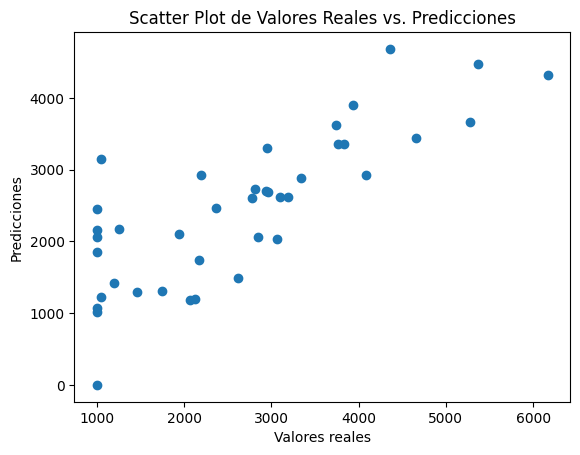

In [ ]:
#Hacer un scatter plot de combined_array
plt.scatter(combined_array[:, 0], combined_array[:, 1])
plt.xlabel('Valores reales')
plt.ylabel('Predicciones')
plt.title('Scatter Plot de Valores Reales vs. Predicciones')
plt.show()

plot_model() genera un diagrama gráfico del modelo de red neuronal creado.

Los parámetros utilizados:

model: La instancia del modelo que hemos definido.

to_file='modelo.png': Guarda la imagen generada como "modelo.png".

show_shapes=True: Muestra la forma (dimensiones) de los tensores en cada capa.

show_layer_names=True: Muestra los nombres de las capas en el gráfico

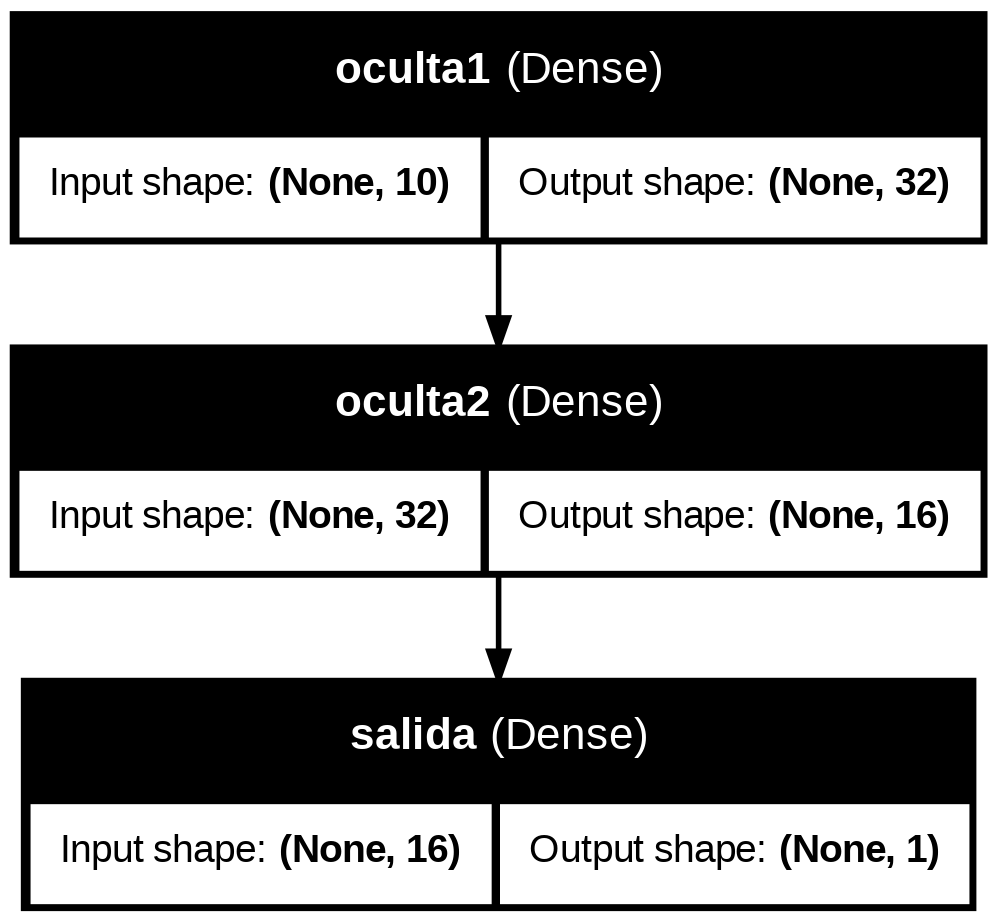

In [ ]:
# Visualizar el modelo
plot_model(model, to_file='modelo.png', show_shapes=True, show_layer_names=True)

In [ ]:
#Persistencia al modelo de la red nuronal entrenada
model.save('modelo_red_neuronal.keras')